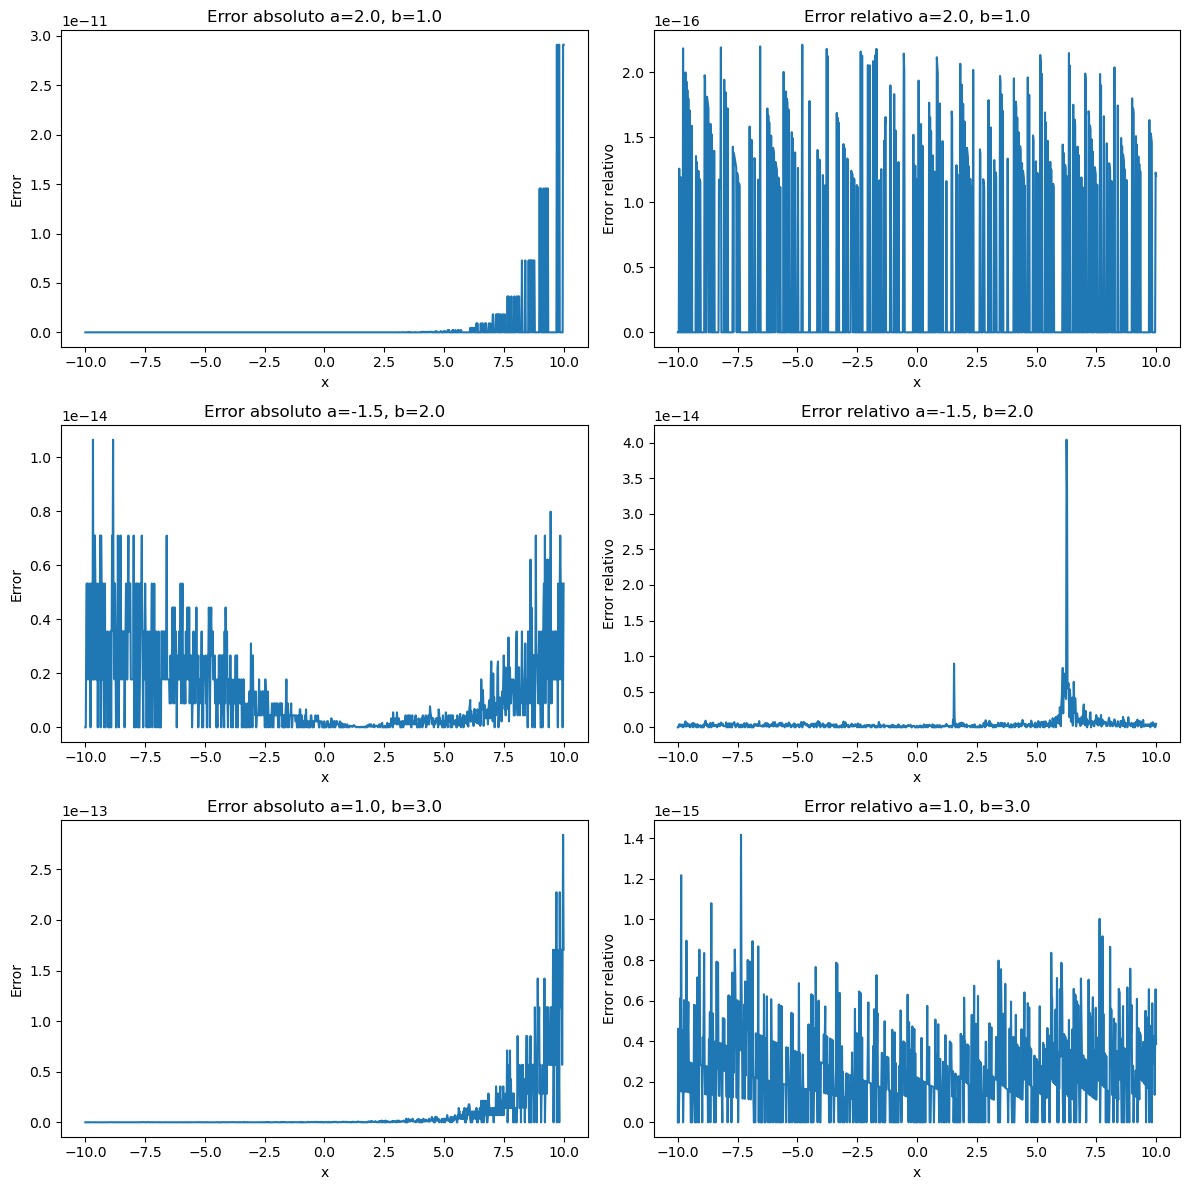

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath
import scipy.special

mpmath.mp.dps = 50  # Precisión alta con mpmath

x_values = np.linspace(-10, 10, 1000)

# Conjuntos de parámetros (a, b) con diferentes características
parametros = [
    (2.0, 1.0),      # a > b, ambos positivos
    (-1.5, 2.0),     # a negativo, b positivo
    (1.0, 3.0),      # a < b, ambos positivos
]

fig, axes = plt.subplots(len(parametros), 2, figsize=(12, 4 * len(parametros)))

for i, (a, b) in enumerate(parametros):
    resultados_mpmath = [mpmath.hyp1f1(a, b, x) for x in x_values]
    resultados_mpmath_float = [float(val.real) for val in resultados_mpmath]
    resultados_scipy = scipy.special.hyp1f1(a, b, x_values)

    error_absoluto = np.abs(np.array(resultados_mpmath_float) - resultados_scipy)
    error_relativo = error_absoluto / (np.abs(resultados_mpmath_float) + 1e-12)

    axes[i, 0].plot(x_values, error_absoluto)
    axes[i, 0].set_title(f'Error absoluto a={a}, b={b}')
    axes[i, 0].set_xlabel('x')
    axes[i, 0].set_ylabel('Error')

    axes[i, 1].plot(x_values, error_relativo)
    axes[i, 1].set_title(f'Error relativo a={a}, b={b}')
    axes[i, 1].set_xlabel('x')
    axes[i, 1].set_ylabel('Error relativo')

plt.tight_layout()
plt.show()


In [2]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = -sp.I * (2*s + 1) / 2 + sp.I * (2*N + 1) / 2
            den = (s + 2) * (s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 1) / 2 + sp.I * (2*N + 1) / 2
            den = (s + 2) * (s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading}  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=1/4

f_1(x) = a1  (x)
f_2(x) = a0  (1 + (i)x^2)
f_3(x) = a1  (x + (i/3)x^3)
f_4(x) = a0  (1 + (2*i)x^2 + (-1/3)x^4)
f_5(x) = a1  (x + (2*i/3)x^3 + (-1/15)x^5)
f_6(x) = a0  (1 + (3*i)x^2 + (-1)x^4 + (-i/15)x^6)
f_7(x) = a1  (x + (i)x^3 + (-1/5)x^5 + (-i/105)x^7)


In [3]:
import sympy as sp

def build_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, N, 2):  
            num = sp.I*(2*s + 1)/2 - sp.I*(2*N + 1)/2   
            den = (s + 2)*(s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, N, 2):  
            num = sp.I*(2*s + 1)/2 - sp.I*(2*N + 1)/2   
            den = (s + 2)*(s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])

    return coeffs, leading

def normalized_coeffs_sympy(N):
    coeffs, leading = build_coeffs_sympy(N)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs], leading

def poly_string_sympy(N, var="x"):
    coeffs_norm, leading = normalized_coeffs_sympy(N)
    leading_name = 'a0' if N % 2 == 0 else 'a1'
    terms = []
    for s, cs in enumerate(coeffs_norm):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(var if s == 1 else "1")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    return (f"f_{N}({var}) = {leading_name}  (" + " + ".join(terms) + ")").replace("I","i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=-1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=-1/4

f_1(x) = a1  (x)
f_2(x) = a0  (1 + (-i)x^2)
f_3(x) = a1  (x + (-i/3)x^3)
f_4(x) = a0  (1 + (-2*i)x^2 + (-1/3)x^4)
f_5(x) = a1  (x + (-2*i/3)x^3 + (-1/15)x^5)
f_6(x) = a0  (1 + (-3*i)x^2 + (-1)x^4 + (i/15)x^6)
f_7(x) = a1  (x + (-i)x^3 + (-1/5)x^5 + (i/105)x^7)


In [4]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading} ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=1, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=1, beta=1/4

f_1(x) = a1 (x)
f_2(x) = a0 (1 + (i/3)x^2)
f_3(x) = a1 (x + (i/6)x^3)
f_4(x) = a0 (1 + (2*i/3)x^2 + (-1/15)x^4)
f_5(x) = a1 (x + (i/3)x^3 + (-1/45)x^5)
f_6(x) = a0 (1 + (i)x^2 + (-1/5)x^4 + (-i/105)x^6)
f_7(x) = a1 (x + (i/2)x^3 + (-1/15)x^5 + (-i/420)x^7)


In [5]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = sp.I * (2*s + 3) / 2 - sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading} ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=1, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=1, beta=1/4

f_1(x) = a1 (x)
f_2(x) = a0 (1 + (-i/3)x^2)
f_3(x) = a1 (x + (i/6)x^3)
f_4(x) = a0 (1 + (-2*i/3)x^2 + (-1/15)x^4)
f_5(x) = a1 (x + (i/3)x^3 + (-1/45)x^5)
f_6(x) = a0 (1 + (-i)x^2 + (-1/5)x^4 + (i/105)x^6)
f_7(x) = a1 (x + (i/2)x^3 + (-1/15)x^5 + (-i/420)x^7)


Polinomios asociados a la ec. hipergeometrica confluente

In [6]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0')  # ya no necesitamos a1

    coeffs = [sp.Integer(0)] * (N + 1)
    coeffs[0] = leading

    a_tr = -2*sp.I*(N*(N-1) + N + sp.Rational(3,4))

    for s in range(0, N):  # paso 1
        num = -(s*(s-1) + s + sp.Rational(3,4) - 2*sp.I*((N*(N-1)) + N+ sp.Rational(3,4)))
        den = (s + 1)
        coeffs[s+1] = sp.simplify((num/den) * coeffs[s])

    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="u"):
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if s == 0:
            terms.append("1")
        else:
            terms.append(f"{sp.simplify(cs)}{var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = a0  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=1/4

f_1(u) = a0  (1 + -3/4 + 7*i/2u^1)
f_2(u) = a0  (1 + -3/4 + 19*i/2u^1 + -1423/32 - 95*i/8u^2)
f_3(u) = a0  (1 + -3/4 + 39*i/2u^1 + -6063/32 - 195*i/8u^2 + 58679/128 - 76349*i/64u^3)
f_4(u) = a0  (1 + -3/4 + 67*i/2u^1 + -17935/32 - 335*i/8u^2 + 520325/384 - 396305*i/64u^3 + 99445515/2048 + 20307365*i/768u^4)
f_5(u) = a0  (1 + -3/4 + 103*i/2u^1 + -42415/32 - 515*i/8u^2 + 1230245/384 - 1449725*i/64u^3 + 581293515/2048 + 74083265*i/768u^4 + -47785843447/24576 + 31953076223*i/12288u^5)
f_6(u) = a0  (1 + -3/4 + 147*i/2u^1 + -86415/32 - 735*i/8u^2 + 835415/128 - 4225025*i/64u^3 + 2451733515/2048 + 71895495*i/256u^4 + -66672869949/8192 + 68227366809*i/4096u^5 + -11083462026315/65536 - 2804721777305*i/16384u^6)
f_7(u) = a0  (1 + -3/4 + 199*i/2u^1 + -158383/32 - 995*i/8u^2 + 4593317/384 - 10493469*i/64u^3 + 8293088203/2048 + 535451489*i/768u^4 + -3371788269779/122880 + 4807472658139*i/61440u^5 + -3479454044091407/2949120 - 64786419415241*i/81920u^6 + 47991

In [7]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0')  # ya no necesitamos a1

    coeffs = [sp.Integer(0)] * (N + 1)
    coeffs[0] = leading

    a_tr = -2*sp.I*(N*(N-1) + N + sp.Rational(3,4))

    for s in range(1, N):  # paso 1
        num = -(s + sp.Rational(1,4) - 2*sp.I*((N + sp.Rational(1,4))))
        den = (s + 1) * s
        coeffs[s+1] = sp.simplify((num/den) * coeffs[s])

    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="u"):
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if s == 0:
            terms.append("1")
        else:
            terms.append(f"{sp.simplify(cs)}{var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = a0  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=1/4

f_1(u) = a0  (1)
f_2(u) = a0  (1)
f_3(u) = a0  (1)
f_4(u) = a0  (1)
f_5(u) = a0  (1)
f_6(u) = a0  (1)
f_7(u) = a0  (1)


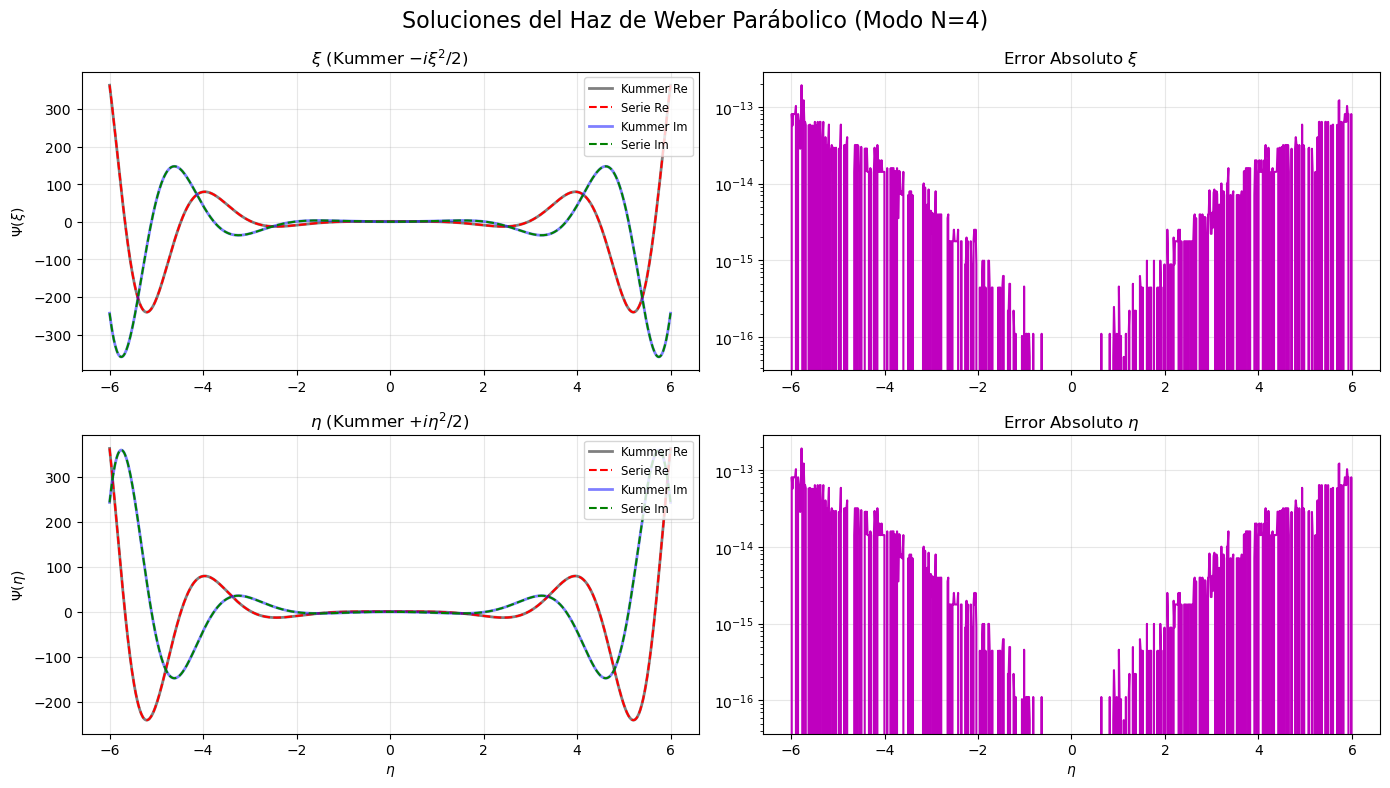

Parametro a (Weber): 4.5
Parametro A (Kummer): -2.0
Ksi (ξ): M(A, 0.5, -iξ²/2) * exp(+iξ²/4)
Eta (η): M(A, 0.5, +iη²/2) * exp(-iη²/4) 


In [22]:
import numpy as np
import mpmath as mp
import matplotlib.pyplot as plt


def a_from_N_even(N: int) -> float:
    return 0.5*(2*N + 1)
#relacion de recurrencia. 
def get_coeffs(N: int):
    c = [0j]*(2*N + 1)
    c[0] = 1.0 + 0j
    c[1] = 0.0 + 0j
    for s in range(0, 2*N, 2):
        num = -1j*(2*s + 1)/2.0 + 1j*(2*N + 1)/2.0
        den = (s + 2)*(s + 1)
        c[s+2] = (num/den)*c[s]
    return np.array(c, dtype=complex)

def series_even(x, N: int, beta_is_imag=True):
 
    x = np.asarray(x, dtype=float)
    c = get_coeffs(N)
    k = np.arange(len(c))[:, None]
    Xk = x[None,:] ** k
    poly = (c[:,None]*Xk).sum(axis=0)
    pref = np.exp((1j if beta_is_imag else 1.0)*0.25*x**2)
    return pref * poly


def kummer_xi_analytic(a_std: float, xi):

    xi = np.asarray(xi, dtype=float)
    A = 0.25 - 0.5*a_std
    B = 0.5

    Z = -0.5j * xi**2  
    
    f = np.vectorize(lambda z: complex(mp.hyp1f1(A, B, z)))
    return np.exp(0.25j * xi**2) * np.array(f(Z), dtype=complex)

def kummer_eta_analytic(a_std: float, eta):
    # Solución para Eta Argumento +i * eta^2 / 2 
    # Prefactor, exp(-i * eta^2 / 4)
    eta = np.asarray(eta, dtype=float)
    A = 0.25 - 0.5*a_std
    B = 0.5
    
    Z = +0.5j * eta**2 
    
    f = np.vectorize(lambda z: complex(mp.hyp1f1(A, B, z)))
    return np.exp(-0.25j * eta**2) * np.array(f(Z), dtype=complex)


def comparar_componentes(N=6, span=(-6, 6), pts=800):
    a_std = a_from_N_even(N)
    u = np.linspace(span[0], span[1], pts)


    y_xi_num = series_even(u, N, beta_is_imag=True)
    y_xi_ana = kummer_xi_analytic(a_std, u)
    
   
    scale_xi = y_xi_ana[len(u)//2] / y_xi_num[len(u)//2]
    y_xi_num_scaled = y_xi_num * scale_xi
    err_xi = np.abs(y_xi_ana - y_xi_num_scaled)


    y_eta_num = np.conj(series_even(u, N, beta_is_imag=True)) 
    y_eta_ana = kummer_eta_analytic(a_std, u)
    
    scale_eta = y_eta_ana[len(u)//2] / y_eta_num[len(u)//2]
    y_eta_num_scaled = y_eta_num * scale_eta
    err_eta = np.abs(y_eta_ana - y_eta_num_scaled)

    # --- PLOT ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"Soluciones del Haz de Weber Parábolico (Modo N={N})", fontsize=16)

    # Gráfica KSI
    ax1 = axes[0, 0]
    ax1.set_title(r"$\xi$ (Kummer $-i\xi^2/2$)")
    ax1.plot(u, y_xi_ana.real, 'k-', lw=2, alpha=0.5, label="Kummer Re")
    ax1.plot(u, y_xi_num_scaled.real, 'r--', label="Serie Re")
    ax1.plot(u, y_xi_ana.imag, 'b-', lw=2, alpha=0.5, label="Kummer Im")
    ax1.plot(u, y_xi_num_scaled.imag, 'g--', label="Serie Im")
    ax1.legend(loc='upper right', fontsize='small')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylabel(r"$\Psi(\xi)$")

    # Error KSI
    ax2 = axes[0, 1]
    ax2.set_title(r"Error Absoluto $\xi$")
    ax2.plot(u, err_xi, 'm')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)

    # Gráfica ETA
    ax3 = axes[1, 0]
    ax3.set_title(r"$\eta$ (Kummer $+i\eta^2/2$)")
    ax3.plot(u, y_eta_ana.real, 'k-', lw=2, alpha=0.5, label="Kummer Re")
    ax3.plot(u, y_eta_num_scaled.real, 'r--', label="Serie Re")
    ax3.plot(u, y_eta_ana.imag, 'b-', lw=2, alpha=0.5, label="Kummer Im")
    ax3.plot(u, y_eta_num_scaled.imag, 'g--', label="Serie Im")
    ax3.legend(loc='upper right', fontsize='small')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlabel(r"$\eta$")
    ax3.set_ylabel(r"$\Psi(\eta)$")

    # Error ETA
    ax4 = axes[1, 1]
    ax4.set_title(r"Error Absoluto $\eta$")
    ax4.plot(u, err_eta, 'm')
    ax4.set_yscale('log')
    ax4.grid(True, alpha=0.3)
    ax4.set_xlabel(r"$\eta$")

    plt.tight_layout()
    plt.show()
    
    # Imprimir detalles de la función utilizada
    print(f"Parametro a (Weber): {a_std}")
    print(f"Parametro A (Kummer): {0.25 - 0.5*a_std}")
    print(f"Ksi (ξ): M(A, 0.5, -iξ²/2) * exp(+iξ²/4)")
    print(f"Eta (η): M(A, 0.5, +iη²/2) * exp(-iη²/4) ")

comparar_componentes(N=4, span=(-6, 6))